In [1]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26

In [41]:
from google.colab import userdata
from roboflow import Roboflow

# gunakan roboflow private api key sendiri
api_key = userdata.get('ROBOFLOW_API_KEY')

rf = Roboflow(api_key=api_key)
project = rf.workspace("hprivs").project("packages-iepao")
version = project.version(15)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to packages-15 in yolov8:: 100%|██████████| 3011/3011 [00:02<00:00, 1161.86it/s]


In [3]:
import torch
if torch.cuda.is_available():
    print(f"CUDA available: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available.")

CUDA available: Tesla T4


In [42]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    name="yolov8n_packages_exp1",
    plots=True,
    patience=4,
    save=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/packages-15/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_packages_exp1-2, nbs=6

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a7863c2abd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [56]:
metrics = model.val()
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2058.8±861.0 MB/s, size: 80.6 KB)
val: Scanning /content/packages-15/valid/labels.cache... 453 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 453/453 118.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 4.3it/s 6.7s
                   all        453       1424      0.666      0.569      0.644      0.413
Speed: 1.9ms preprocess, 3.6ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP@50: 0.6435
mAP@50-95: 0.4132


In [64]:
best_model_path = "runs/detect/yolov8n_packages_exp1/weights/best.pt"
best_model = YOLO(best_model_path)
best_model.model.names[0] = "packages"

results = best_model.predict(
    source=f"{dataset.location}/valid/images",
    save=True,
    conf=0.4
)


image 1/453 /content/packages-15/valid/images/-E9-98-B2-E6-BD-AE-E7-BA-B8-E7-AE-B1_jpg.rf.898d141dc56c2b5fc9792c137eeddf3b.jpg: 480x640 1 packages, 6.0ms
image 2/453 /content/packages-15/valid/images/01f96c563dc9f832f87512f6ecf309-jpg-1_jpg.rf.3f99b5b0aebb4e570c5a509f947f2946.jpg: 640x640 3 packagess, 7.8ms
image 3/453 /content/packages-15/valid/images/094210271_png.rf.8aa0500be1573c1e2964dbed76b79ad5.jpg: 640x544 (no detections), 7.7ms
image 4/453 /content/packages-15/valid/images/0d338744ebf81a4cf189472fd92a6059242d_jpg.rf.b57ea86f95fb34f4edf73be7bdfc2af0.jpg: 480x640 3 packagess, 6.7ms
image 5/453 /content/packages-15/valid/images/1-1-768x768_jpg.rf.1b8822f375e05afb1e04b4d9780afce9.jpg: 640x640 7 packagess, 7.9ms
image 6/453 /content/packages-15/valid/images/1-1P321212924X4-lp_jpg.rf.2dad1408be285e904d0efdce9cc49108.jpg: 640x640 2 packagess, 7.2ms
image 7/453 /content/packages-15/valid/images/1-200H31K64V24_jpg.rf.feca11adde1556cd25a82b03774339b8.jpg: 480x640 6 packagess, 6.7ms
ima

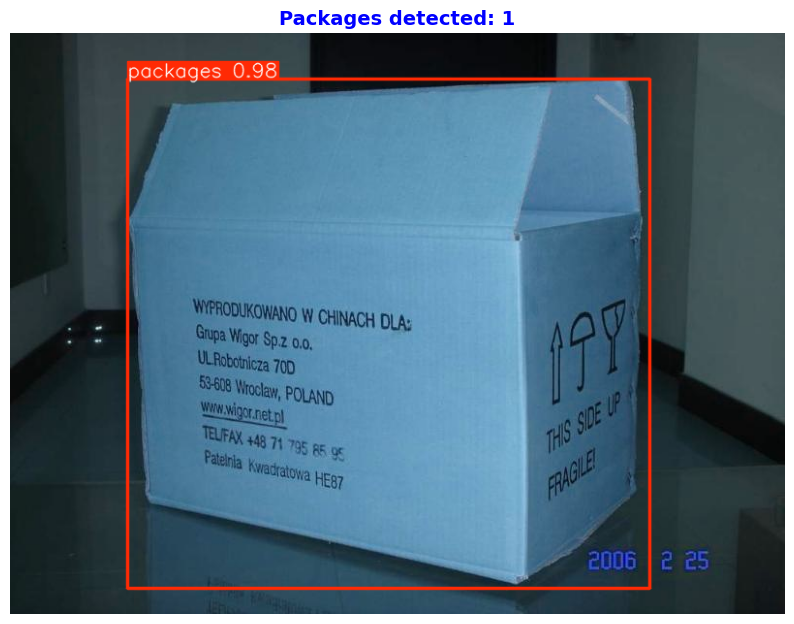

In [71]:
import matplotlib.pyplot as plt

image1 = results[0]
img = image1.plot()

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"Packages detected: {len(image1.boxes)}", fontsize=14, color='blue', fontweight='bold')
plt.axis('off')
plt.show()


image 1/1 /content/IMG_20260810_134631.jpg: 640x480 1 packages, 12.9ms
Speed: 4.3ms preprocess, 12.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


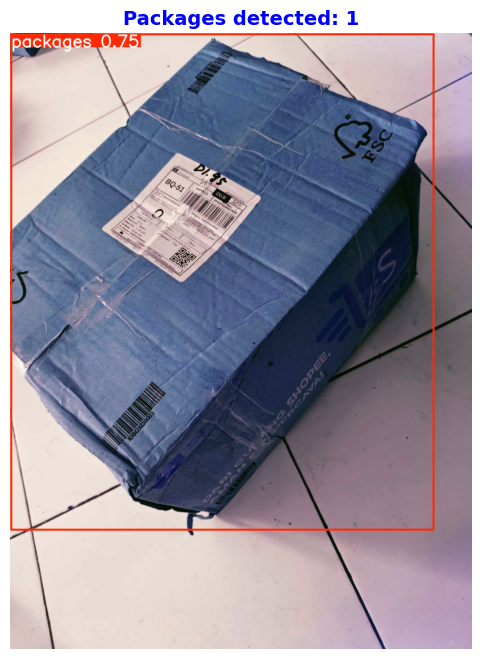

In [66]:
test_sample = best_model.predict(
    source="/content/IMG_20260810_134631.jpg",
    conf=0.4
)

img = test_sample[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"Packages detected: {len(test_sample[0].boxes)}", fontsize=14, color='blue', fontweight='bold')
plt.axis('off')
plt.show()


image 1/1 /content/POD_MultiplePackages.jpg: 640x640 5 packagess, 7.3ms
Speed: 2.8ms preprocess, 7.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


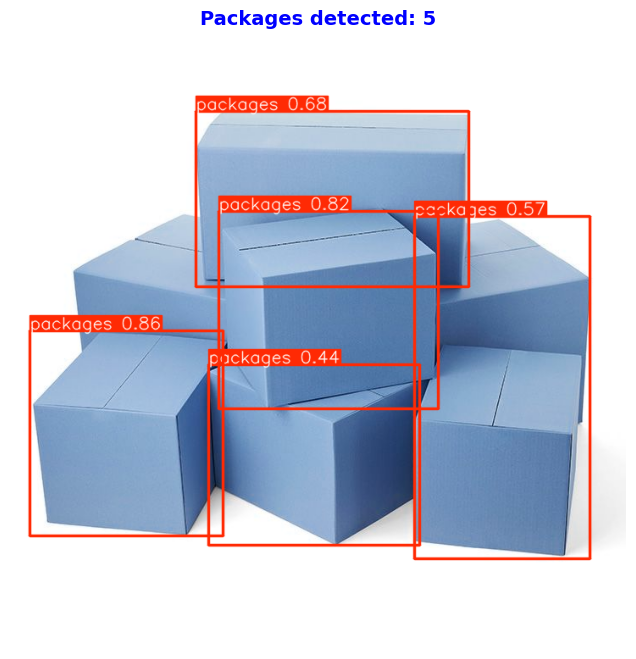

In [70]:
test_sample2 = best_model.predict(
    source="/content/POD_MultiplePackages.jpg",
    conf=0.4,
)

img = test_sample2[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"Packages detected: {len(test_sample2[0].boxes)}", fontsize=14, color='blue', fontweight='bold')
plt.axis('off')
plt.show()